In [155]:
#Đọc dữ liệu csv

import pandas as pd

pd.set_option('display.max_rows', None)
df = pd.read_csv("Fish.csv")

df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.00,23.20,25.40,30.00,11.52,4.02
1,Bream,290.00,24.00,26.30,31.20,12.48,4.31
2,Bream,340.00,23.90,26.50,31.10,12.38,4.70
3,Bream,363.00,26.30,29.00,33.50,12.73,4.46
4,Bream,430.00,26.50,29.00,34.00,12.44,5.13


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [157]:
# Tạo đặc trưng mới 'EstimatedVolume' từ 'Length1', 'Length2', 'Height'
df['EstimatedVolume'] = df['Length1'] * df['Length2'] * df['Height']

# Tạo đặc trưng mới 'EstimatedSurfaceArea' từ từ 'Length1', 'Length2', 'Height'
df['EstimatedSurfaceArea'] = 2 * (df['Length1'] * df['Length2'] + df['Length1'] * df['Height'] + df['Length2'] * df['Height'])

# Tạo đặc trưng 'Size_Group': phân loại kích thước cá, nhỏ thì cá kích thước phải dưới 25, vừa thì trên 25 dưới 30, trên 30 là lớn
df['Average_Size'] = df[['Length1', 'Length2', 'Length3']].mean(axis=1)
def categorize_size(average_size):
    if average_size < 25:
        return 'Small'
    elif average_size >= 25 and average_size < 30:
        return 'Medium'
    else:
        return 'Large'

df['Size_Group'] = df['Average_Size'].apply(categorize_size)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,EstimatedVolume,EstimatedSurfaceArea,Average_Size,Size_Group
0,Bream,242.00,23.20,25.40,30.00,11.52,4.02,6788.51,2298.30,26.20,Medium
1,Bream,290.00,24.00,26.30,31.20,12.48,4.31,7877.38,2517.89,27.17,Medium
2,Bream,340.00,23.90,26.50,31.10,12.38,4.70,7839.48,2514.38,27.17,Medium
3,Bream,363.00,26.30,29.00,33.50,12.73,4.46,9709.17,2933.34,29.60,Medium
4,Bream,430.00,26.50,29.00,34.00,12.44,5.13,9563.21,2918.28,29.83,Medium


In [158]:
# Mã hóa các biến phân loại 'Species', 'Size_Group'
df = pd.get_dummies(df, columns=['Species', 'Size_Group'], drop_first=False)

# Hiển thị dữ liệu sau khi mã hóa
pd.set_option('display.max_columns', None)
df.head()

,Weight,Length1,Length2,Length3,Height,Width,EstimatedVolume,EstimatedSurfaceArea,Average_Size,Species_Bream,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish,Size_Group_Large,Size_Group_Medium,Size_Group_Small
0,242.00,23.20,25.40,30.00,11.52,4.02,6788.51,2298.30,26.20,1,0,0,0,0,0,0,0,1,0
1,290.00,24.00,26.30,31.20,12.48,4.31,7877.38,2517.89,27.17,1,0,0,0,0,0,0,0,1,0
2,340.00,23.90,26.50,31.10,12.38,4.70,7839.48,2514.38,27.17,1,0,0,0,0,0,0,0,1,0
3,363.00,26.30,29.00,33.50,12.73,4.46,9709.17,2933.34,29.60,1,0,0,0,0,0,0,0,1,0
4,430.00,26.50,29.00,34.00,12.44,5.13,9563.21,2918.28,29.83,1,0,0,0,0,0,0,0,1,0


In [161]:
from sklearn.preprocessing import StandardScaler
# Xác định các cột cần chuẩn hóa
numerical_features = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width', 'EstimatedVolume', 'EstimatedSurfaceArea', 'Average_Size']

# Sử dụng StandardScaler để chuẩn hóa dữ liệu
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Hiển thị dữ liệu sau khi chuẩn hóa
df.head()

,Weight,Length1,Length2,Length3,Height,Width,EstimatedVolume,EstimatedSurfaceArea,Average_Size,Species_Bream,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish,Size_Group_Large,Size_Group_Medium,Size_Group_Small
0,-0.44,-0.31,-0.28,-0.11,0.60,-0.24,-0.28,-0.26,-0.23,1,0,0,0,0,0,0,0,1,0
1,-0.30,-0.23,-0.20,-0.00,0.82,-0.07,-0.14,-0.15,-0.14,1,0,0,0,0,0,0,0,1,0
2,-0.16,-0.24,-0.18,-0.01,0.80,0.17,-0.15,-0.15,-0.14,1,0,0,0,0,0,0,0,1,0
3,-0.10,0.01,0.05,0.20,0.88,0.02,0.08,0.07,0.09,1,0,0,0,0,0,0,0,1,0
4,0.09,0.03,0.05,0.24,0.81,0.43,0.06,0.06,0.11,1,0,0,0,0,0,0,0,1,0


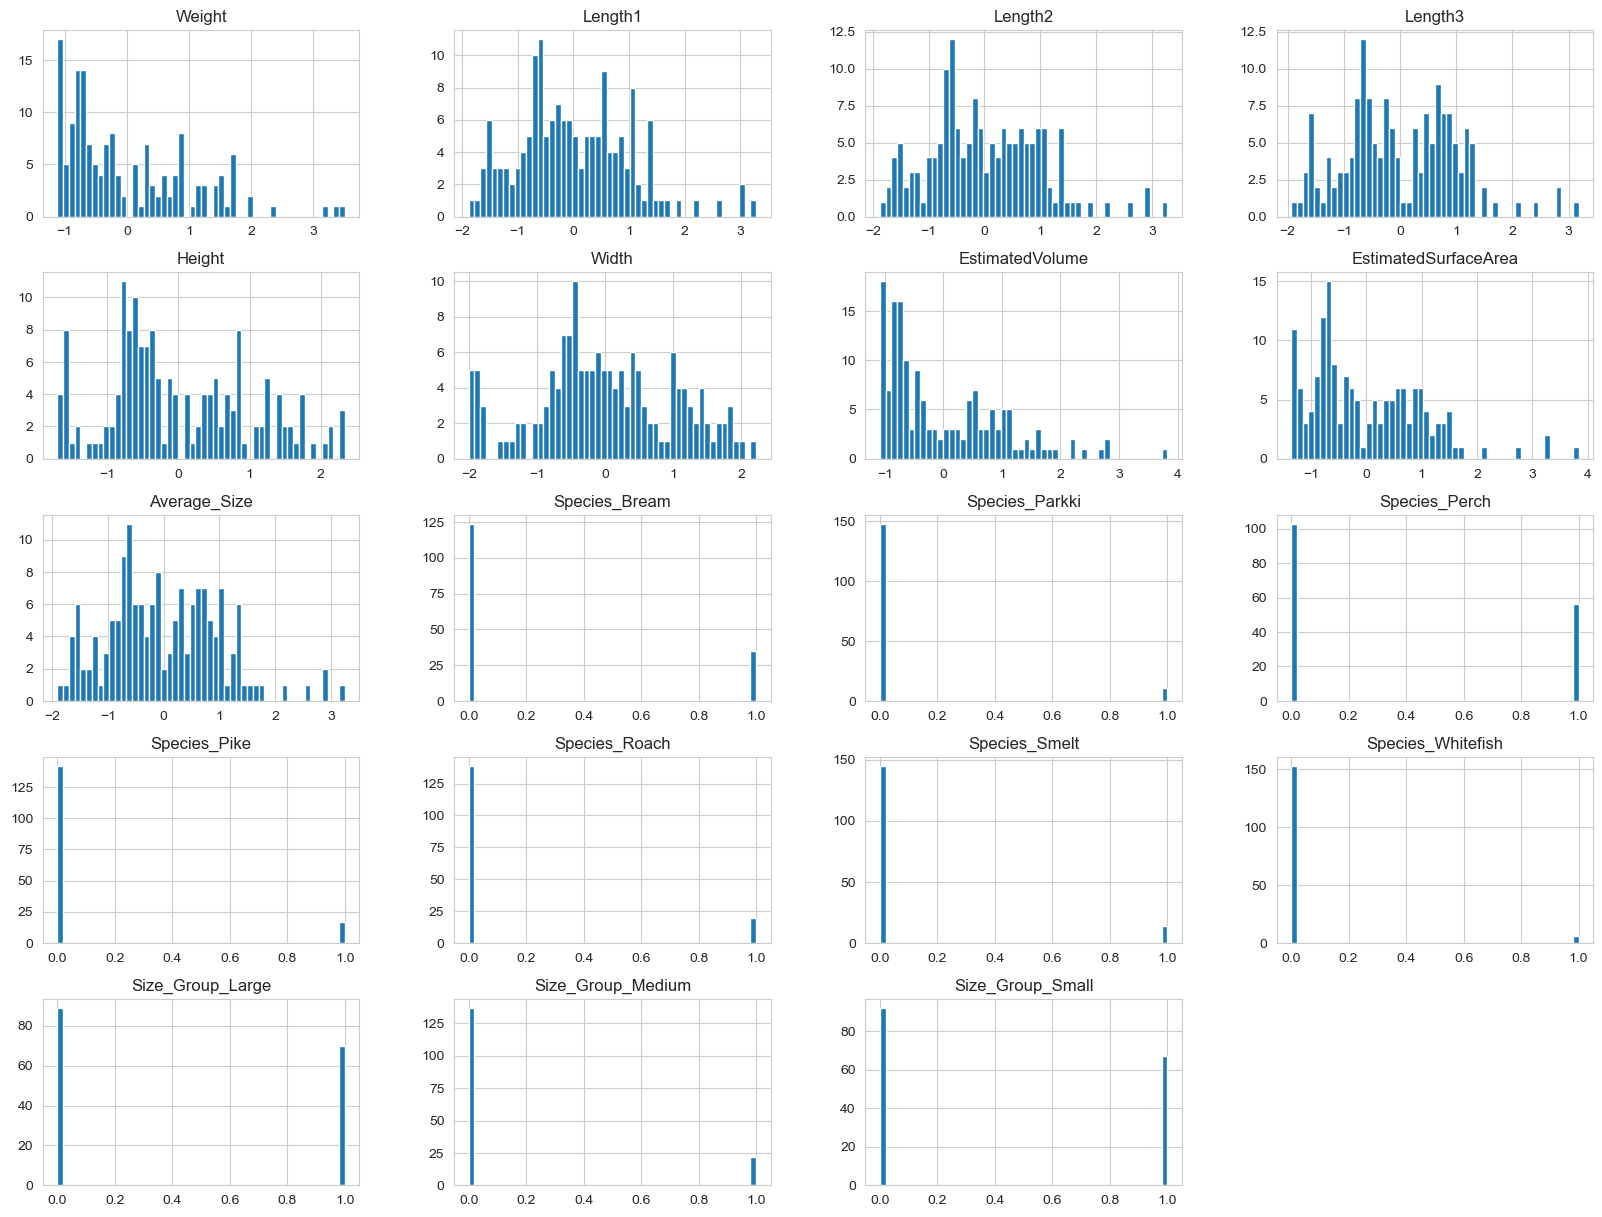

In [163]:
#Visualize data
%matplotlib inline
import matplotlib.pyplot as plt
df.hist(bins = 50, figsize=(20,15))
plt.show()

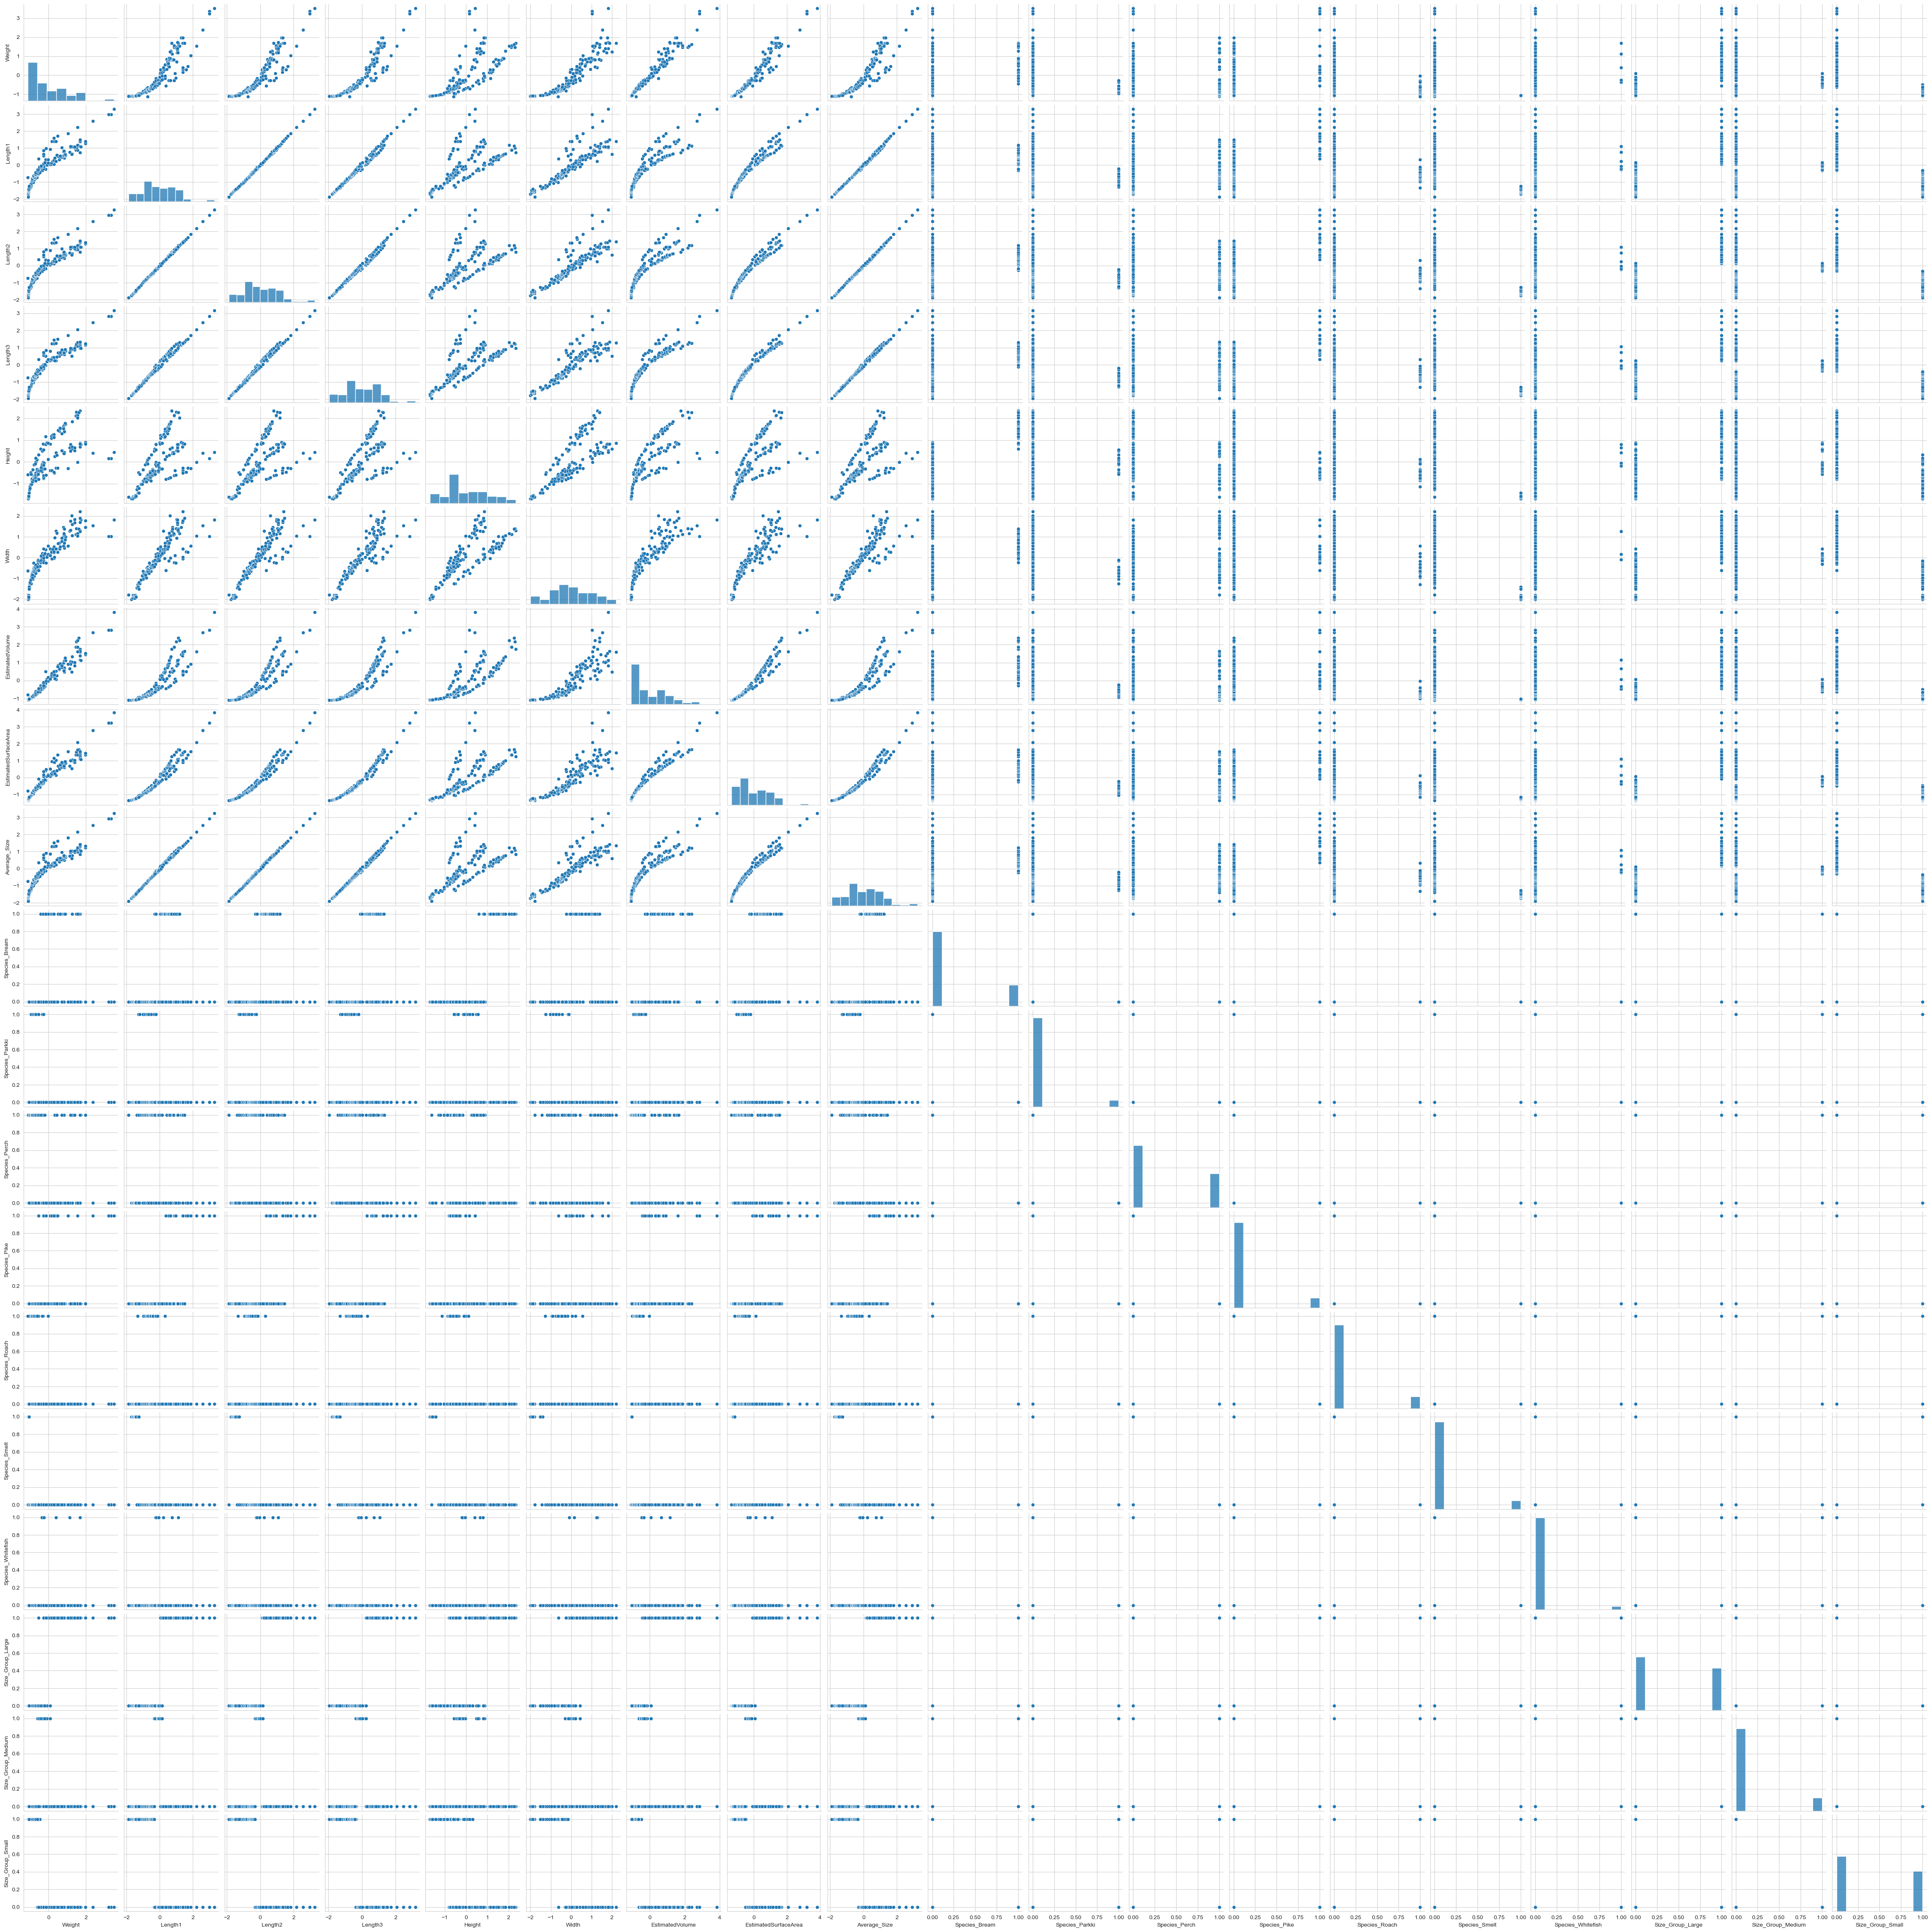

In [164]:
import seaborn as sns
sns.pairplot(df)

C:\Users\minhk\AppData\Local\Temp\ipykernel_13764\4222603823.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='Weight'>

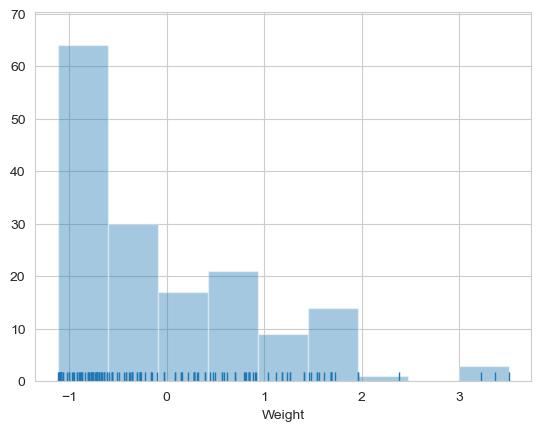

In [165]:
sns.set_style("whitegrid")
sns.distplot(df['Weight'], kde = False, rug = "True")

<Axes: >

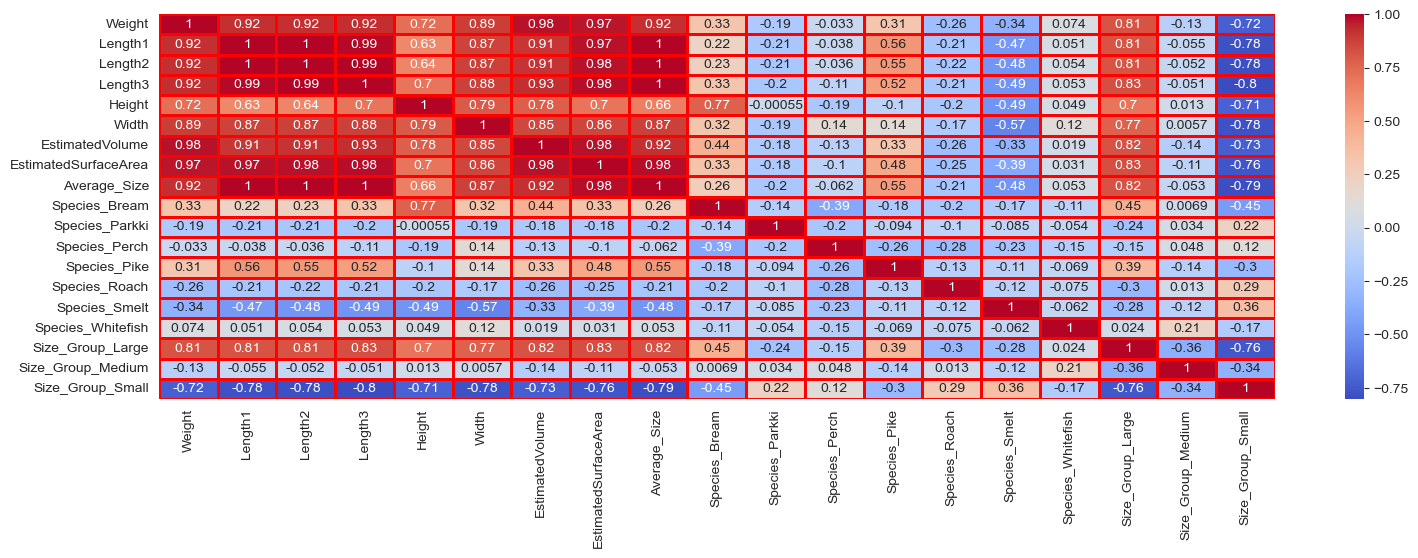

In [166]:
plt.figure(figsize=(18,5))
sns.heatmap(df.corr(), annot=True, lw = 1, linecolor="r",cmap="coolwarm")

In [167]:
#Mô hình Linear Regression
#Ta sẽ xây dựng một bài toán dự đoán trọng lượng của con cá, dựa vào 'EstimatedVolume', 'EstimatedSurfaceArea', 'Average_Size'.
X = df[['EstimatedVolume', 'EstimatedSurfaceArea', 'Average_Size']]
Y = df['Weight']

In [168]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=101)

In [169]:
X_train

,EstimatedVolume,EstimatedSurfaceArea,Average_Size
109,0.12,0.25,0.35
23,1.00,0.78,0.67
6,0.27,0.21,0.16
51,-0.59,-0.48,-0.29
88,-0.78,-0.73,-0.63
14,0.61,0.48,0.40
82,-0.83,-0.81,-0.73
3,0.08,0.07,0.09
118,1.06,1.01,0.96
91,-0.77,-0.72,-0.59


In [170]:
y_train

109    0.32
23     0.79
6      0.28
51    -0.61
88    -0.75
14     0.57
82    -0.81
3     -0.10
118    1.18
91    -0.75
89    -0.74
157   -1.06
58     0.40
130   -0.28
2     -0.16
45    -0.67
9      0.28
54    -0.02
47    -0.67
46    -0.72
26     0.90
123    1.97
27     0.88
20     0.50
147   -1.10
151   -1.09
30     1.46
35    -1.00
133   -0.15
117    0.71
121    1.73
24     0.85
93    -0.71
97    -0.71
79    -0.89
152   -1.09
17     0.85
12     0.28
0     -0.44
135    0.31
15     0.57
112    0.80
71    -0.28
18     0.59
114    0.85
125    1.97
146   -1.10
38    -0.87
103   -0.39
56    -0.36
52    -0.30
10     0.21
7     -0.02
148   -1.09
28     1.27
99    -0.61
141    2.39
36    -0.92
62    -0.95
8      0.14
144    3.51
73    -1.03
119    1.27
105   -0.42
128   -0.56
153   -1.09
107   -0.28
76    -0.92
126    1.69
19     0.71
72    -1.10
44    -0.71
59     1.13
138    0.47
115    0.82
136    0.40
111    1.24
83    -0.79
49    -0.67
150   -1.09
140    1.55
5      0.14
110    0.44
60  

In [171]:
X_test

,EstimatedVolume,EstimatedSurfaceArea,Average_Size
127,1.65,1.54,1.42
42,-0.80,-0.78,-0.68
55,-0.48,-0.39,-0.24
101,-0.52,-0.38,-0.20
33,2.38,1.67,1.19
124,1.39,1.36,1.31
78,-0.90,-0.94,-0.96
143,2.83,3.22,2.93
16,0.71,0.57,0.49
74,-1.01,-1.13,-1.28


In [172]:
#Tách dữ liệu train - test rồi, tạo model:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

In [173]:
#Dự đoán và đánh giá mô hình:
predictions = lm.predict(X_test)

predictions

array([ 1.62959892, -0.76541359, -0.44026027, -0.48623715,  2.35399183,
        1.37203019, -0.8987372 ,  2.65374831,  0.71479823, -1.024936  ,
        0.91589295, -0.69653583, -0.80179753, -0.7775814 , -0.35317942,
       -0.79845355, -0.86509521, -0.69421604,  0.08062532, -0.13625157,
        2.14436094, -0.76177563, -0.77649769, -0.59505022, -1.09205651,
        1.84818682,  0.42409768, -0.37803311, -1.10022057, -1.03575735,
        2.65374831, -0.60652214, -0.60830874, -0.57685862, -0.49302219,
        0.49240202, -0.05220392, -0.606625  ,  1.11230778, -0.28492962,
       -1.1635854 , -1.12796606, -0.74543256, -0.26708376,  0.83361919,
       -0.74790709, -0.76950209, -0.74034512, -0.71556289, -0.57843664,
       -0.66377777,  0.96671991,  0.94942853,  1.73196608, -0.86093677,
        0.88146317, -0.98403605,  1.01378184,  0.50748707, -0.29738379,
       -0.91454794, -0.37637657,  2.22835101, -0.45886505])

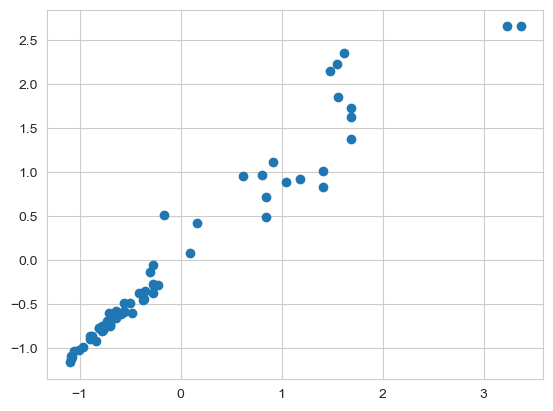

In [174]:
#Sử dụng biểu đồ phân tán (scatter)
plt.scatter(y_test,predictions)

In [175]:
#Sử dụng biểu đồ cufflinks
import cufflinks as cf 
cf.go_offline()
import plotly.io as pio
pio.renderers.default = "colab"
pd.DataFrame({"Trọng lượng dự đoán":predictions, "Trọng lượng ban đầu": y_test}).iplot(mode="markers")

C:\Users\minhk\AppData\Local\Temp\ipykernel_13764\1181080564.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='Weight', ylabel='Density'>

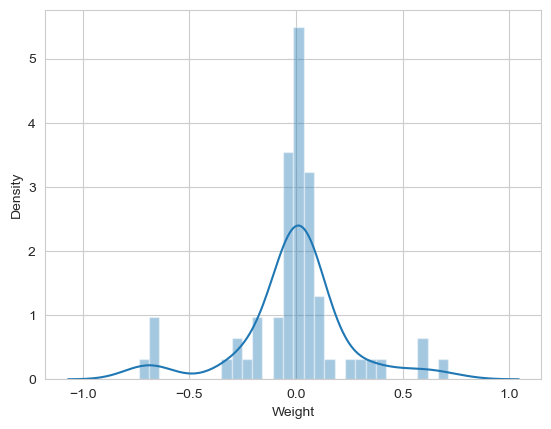

In [176]:
sns.distplot(y_test - predictions)

In [177]:
#Tính giá trị hàm mất mát MSE
from sklearn import metrics
print('MSE:', metrics.mean_squared_error(y_test, predictions))

MSE: 0.06354787214597657


In [178]:
#Kiểm tra độ chính xác mô hình trên dựa trên phương sai
metrics.explained_variance_score(y_test, predictions)

0.9435043112538677